# Phase 5: Explainable AI (XAI)

This notebook explains why the trained churn model (from
`03_model_training.ipynb`) makes its predictions, using tree-based feature
importance and SHAP values.

**Objectives**
- Load the trained model and test dataset
- Inspect global feature importance
- Explain individual predictions with SHAP (waterfall, force, decision plots)
- Generate a per-customer explanation report
- Derive business recommendations

## 1. Setup

In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

warnings.filterwarnings("ignore")

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
REPORTS_DIR = "../reports"

FINAL_MODEL_PKL = os.path.join(MODELS_DIR, "final_churn_model.pkl")
X_TEST_CSV = os.path.join(DATA_DIR, "X_test.csv")
Y_TEST_CSV = os.path.join(DATA_DIR, "y_test.csv")

FEATURE_IMPORTANCE_CSV = os.path.join(REPORTS_DIR, "feature_importance.csv")
CUSTOMER_EXPLANATION_CSV = os.path.join(REPORTS_DIR, "customer_explanation.csv")

## 2. Load Model and Dataset

In [2]:
model = joblib.load(FINAL_MODEL_PKL)
X_test = pd.read_csv(X_TEST_CSV)
y_test = pd.read_csv(Y_TEST_CSV).squeeze()

print(type(model))
print(X_test.shape)
print(y_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(1409, 51)
(1409,)


## 3. SHAP Explainer

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive
feature contributions that sum to the model output, giving a consistent,
model-agnostic notion of feature importance.

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Newer SHAP versions return a 3-D array (samples, features, classes);
# older versions return a list of 2-D arrays. Normalize to the array form.
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)

print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1409, 51, 2)


## 4. Global Feature Importance (Tree-Based)

Mean decrease in impurity (the model's built-in `feature_importances_`),
averaged over the forest's trees.

In [4]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
38,cat__Contract_Month-to-month,0.109800
0,num__Tenure Months,0.108875
2,num__Total Charges,0.086351
3,num__Avg Monthly Spend,0.065312
1,num__Monthly Charges,0.064103
20,cat__Online Security_No,0.051403
29,cat__Tech Support_No,0.048466
18,cat__Internet Service_Fiber optic,0.046706
49,cat__Customer Age Group_New,0.044962
10,cat__Dependents_No,0.035103


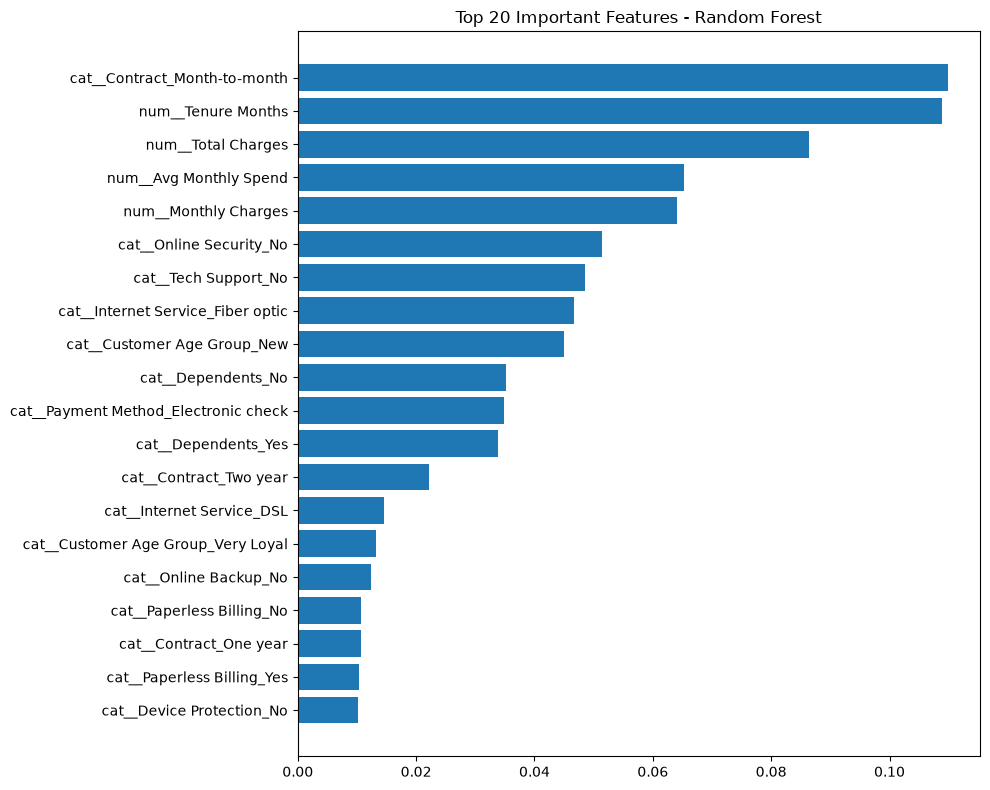

In [5]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(20)["Feature"], feature_importance.head(20)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - Random Forest")
plt.tight_layout()
plt.show()

## 5. SHAP Beeswarm Plot

Each dot is a test customer; the horizontal position is the SHAP value for that
feature (positive pushes toward churn, negative away from it). Color shows the
feature value (red = high, blue = low).

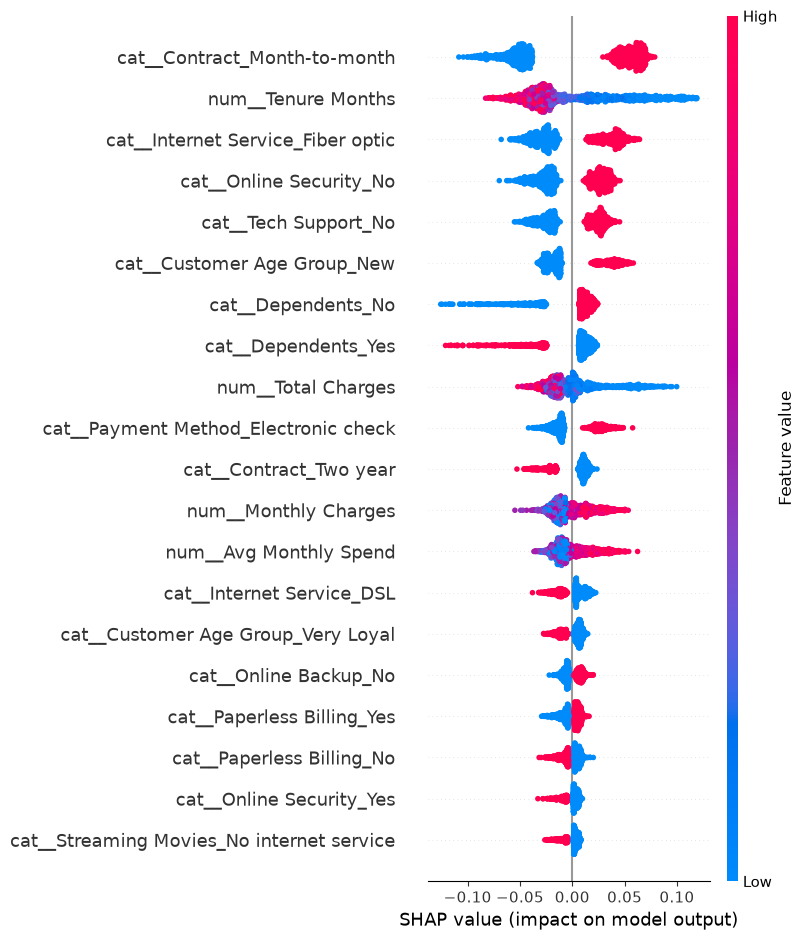

In [6]:
shap.summary_plot(shap_values[:, :, 1], X_test)

## 6. SHAP Feature Importance

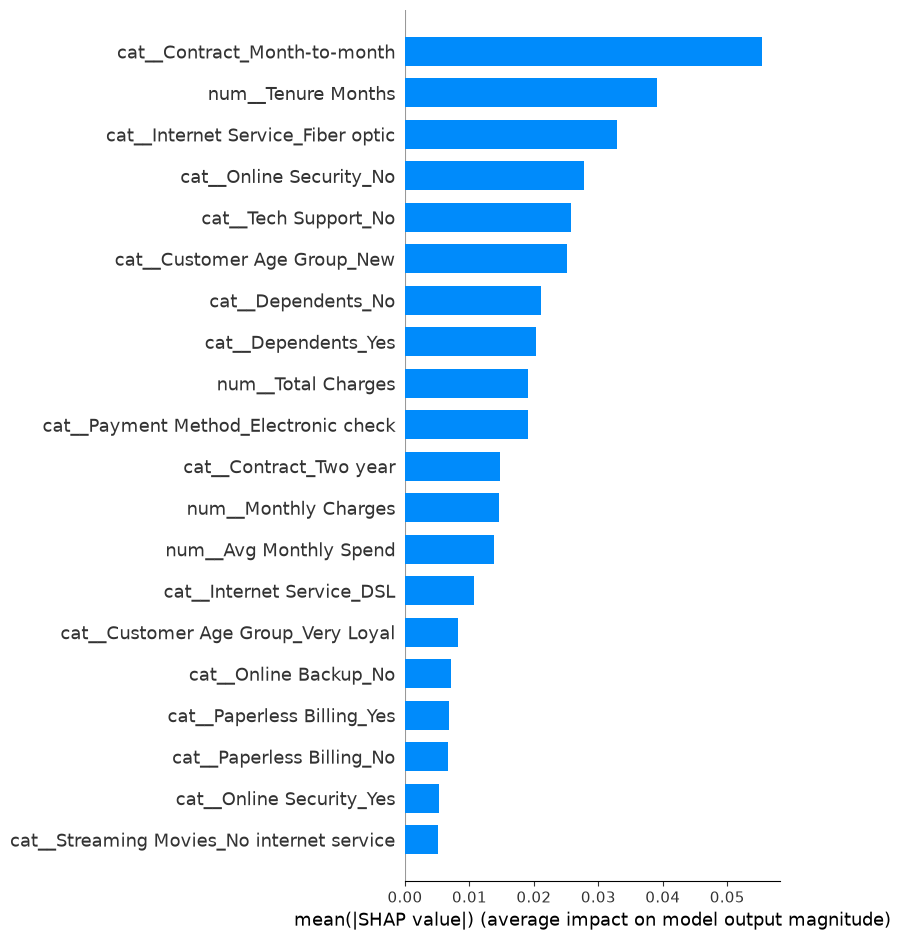

In [7]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

## 7. Explain One Customer

The first test customer (`sample_index = 0`) is explained in detail. The
positive class (`class_index = 1`) is churn.

In [8]:
sample_index = 0
class_index = 1

In [9]:
sample_row = X_test.iloc[[sample_index]]

prediction = model.predict(sample_row)[0]
probability = model.predict_proba(sample_row)[0][1]

print("Prediction:", prediction)
print("Probability:", round(probability, 4))

Prediction: 0
Probability: 0.0374


## 8. Waterfall Plot

Shows how the model's base rate is pushed toward or away from churn by each
feature for the selected customer.

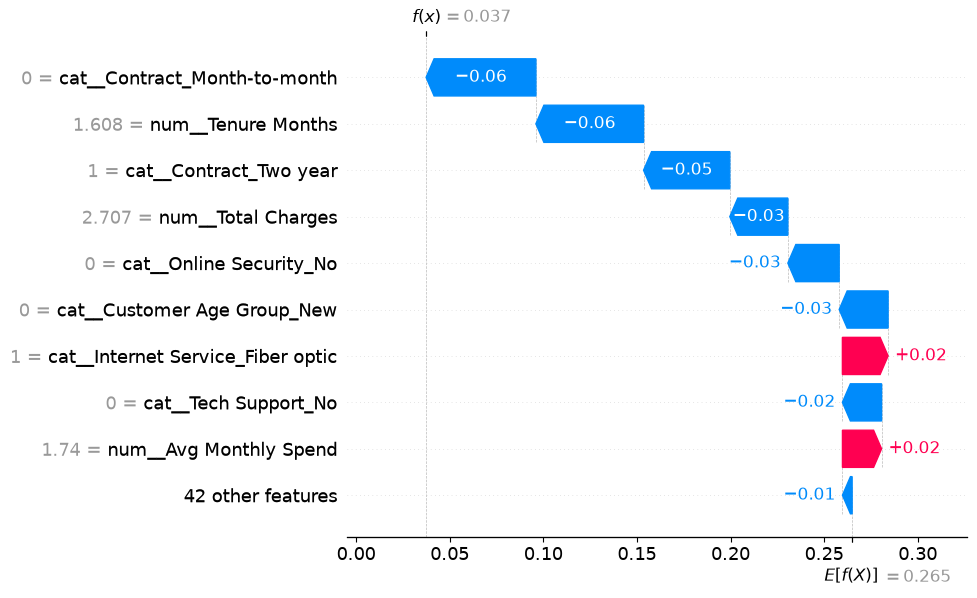

In [10]:
explanation = shap.Explanation(
    values=shap_values[sample_index, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation)

## 9. Force Plot

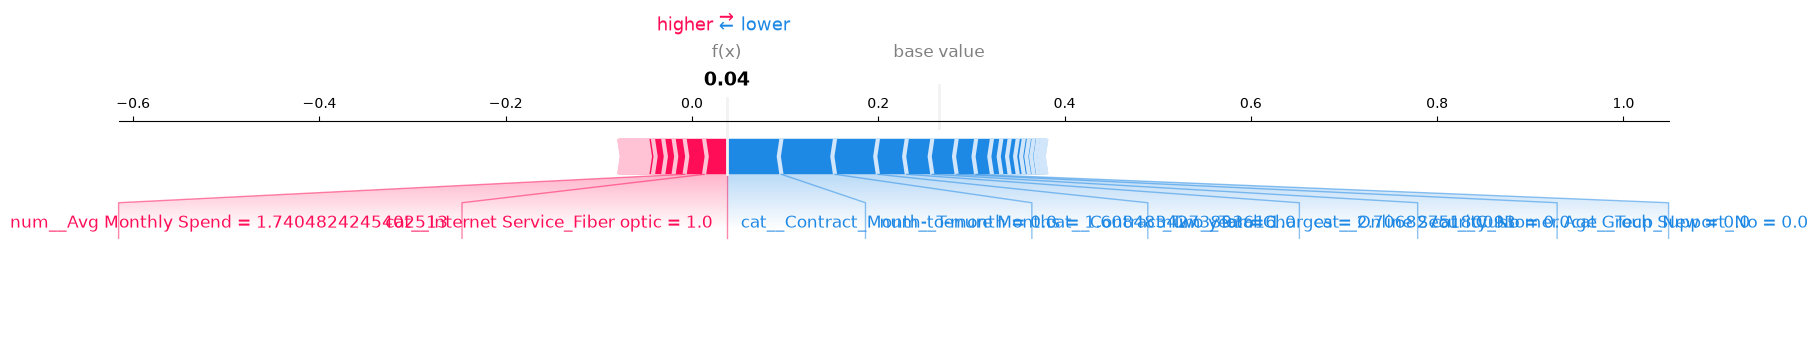

In [11]:
shap.plots.force(explanation, matplotlib=True)

## 10. Decision Plot

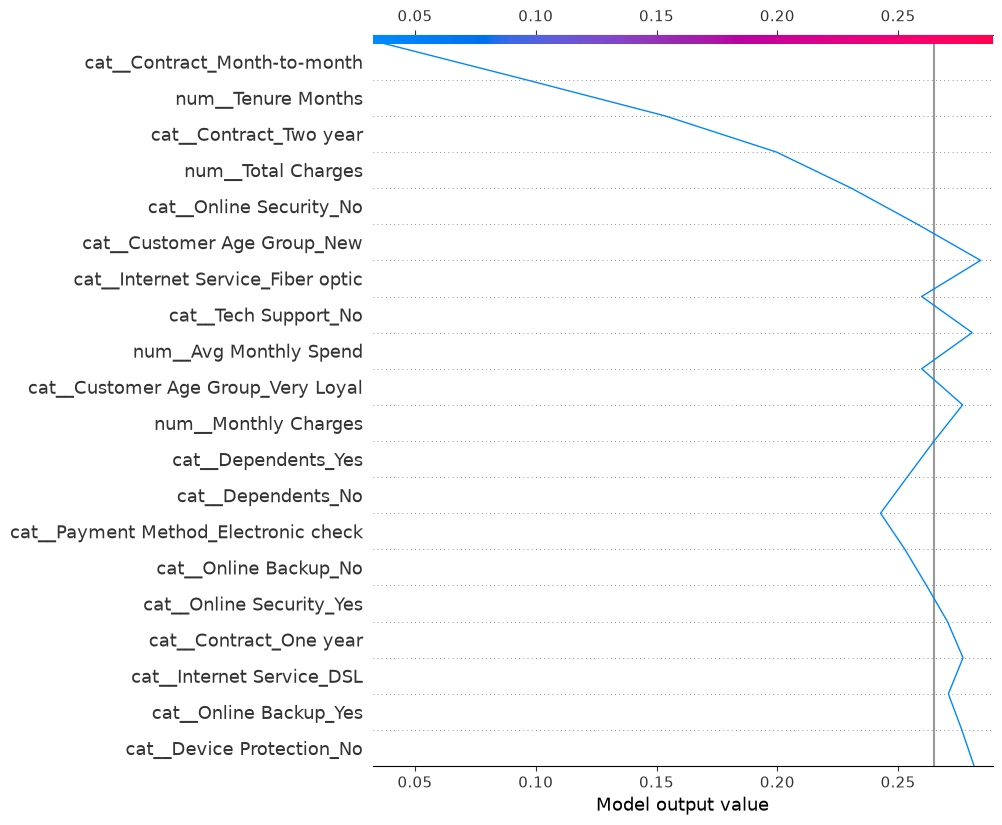

In [12]:
shap.decision_plot(
    explainer.expected_value[class_index],
    shap_values[sample_index, :, class_index],
    feature_names=X_test.columns.tolist()
)

## 11. Customer Explanation Report

`SHAP Value` is the contribution of each feature to the churn prediction;
`Impact` labels whether that contribution increases or decreases churn risk.

In [13]:
customer_report = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_values[sample_index, :, class_index],
    "Customer Value": X_test.iloc[sample_index].values
})

customer_report["Impact"] = np.where(
    customer_report["SHAP Value"] > 0,
    "Increase Churn Risk",
    "Decrease Churn Risk"
)

customer_report = customer_report.sort_values(
    by="SHAP Value", key=abs, ascending=False
)

customer_report.head(20)

,Feature,SHAP Value,Customer Value,Impact
38,cat__Contract_Month-to-month,-0.058652,0.000000,Decrease Churn Risk
0,num__Tenure Months,-0.057509,1.608483,Decrease Churn Risk
40,cat__Contract_Two year,-0.046058,1.000000,Decrease Churn Risk
2,num__Total Charges,-0.031012,2.706828,Decrease Churn Risk
20,cat__Online Security_No,-0.027422,0.000000,Decrease Churn Risk
49,cat__Customer Age Group_New,-0.026126,0.000000,Decrease Churn Risk
18,cat__Internet Service_Fiber optic,0.024414,1.000000,Increase Churn Risk
29,cat__Tech Support_No,-0.020935,0.000000,Decrease Churn Risk
3,num__Avg Monthly Spend,0.020906,1.740482,Increase Churn Risk
50,cat__Customer Age Group_Very Loyal,-0.016943,1.000000,Decrease Churn Risk


## 12. Business Recommendations

Illustrative rules derived from the top SHAP features for the selected
customer. These are heuristics for demonstration, not a data-driven policy.

In [14]:
recommendations = []

for _, row in customer_report.head(5).iterrows():
    feature = row["Feature"]

    if "Contract" in feature:
        recommendations.append("Offer long-term contract incentives.")
    elif "Monthly Charges" in feature:
        recommendations.append("Provide personalized pricing or discounts.")
    elif "Tech Support" in feature:
        recommendations.append("Promote premium technical support.")
    elif "Online Security" in feature:
        recommendations.append("Bundle online security services.")
    elif "Tenure" in feature:
        recommendations.append("Offer loyalty rewards.")

recommendations = list(dict.fromkeys(recommendations))
recommendations

['Offer long-term contract incentives.',
 'Offer loyalty rewards.',
 'Bundle online security services.']

## 13. Save Reports

In [15]:
feature_importance.to_csv(FEATURE_IMPORTANCE_CSV, index=False)
print("Saved:", os.path.exists(FEATURE_IMPORTANCE_CSV))

Saved: True


In [16]:
customer_report.to_csv(CUSTOMER_EXPLANATION_CSV, index=False)
print("Saved:", os.path.exists(CUSTOMER_EXPLANATION_CSV))

Saved: True


## 14. Phase Summary

In [17]:
summary = {
    "Model": "Random Forest",
    "Explainer": "TreeExplainer",
    "Test Samples": X_test.shape[0],
    "Features": X_test.shape[1],
    "Top Feature": feature_importance.iloc[0]["Feature"],
    "Prediction": prediction,
    "Prediction Probability": round(probability, 4)
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Model,Random Forest
1,Explainer,TreeExplainer
2,Test Samples,1409
3,Features,51
4,Top Feature,cat__Contract_Month-to-month
5,Prediction,0
6,Prediction Probability,0.0374
